In [21]:
import numpy as np
import ray
import matplotlib.pyplot as plt

# WannierBerri k.p

In [2]:
import numpy as np

class FerroaxialHam3D:
    def __init__(self, mu=0.0, t=1.0, tp=1.0, Delta=1.0, tpz=1.0, tc=0.0, a=1.0, c=1.0):
        self.mu = mu
        self.t = t
        self.tp = tp
        self.Delta = Delta
        self.tpz = tpz
        self.tc = tc

        #a = 1
        # 1. Lattice Vectors (AA-stacked Honeycomb)
        self.a1 = (a/2) * np.array([3, np.sqrt(3), 0]) # Γ - M line along the x axis 
        self.a2 = (a/2) * np.array([3,-np.sqrt(3), 0])
        #self.a3 = a * np.array([0, 0, 1]) 
        self.a3 = np.array([0, 0, c])
        # 2. Nearest-Neighbor Vectors (A to B sublattice in the XY plane)
        # Adjust these if your Julia code used a different orientation
        self.d1 = a/2 * np.array([1, np.sqrt(3), 0])
        self.d2 = a/2 * np.array([1, -np.sqrt(3), 0])
        self.d3 = a * np.array([-1, 0, 0])

        self.ds = np.array([self.d1, self.d2, self.d3])
        self.d_up = self.ds + self.a3
        self.d_dn = self.ds - self.a3        

    def evaluate_H(self, k):
        
        """
        Returns the 2x2 Hamiltonian matrix for a given k-point.
        k: array-like [kx, ky, kz]
        """

        # first neighbour hoppings 
        #fk =  sum(np.exp(1j * np.dot(k, delta)) for delta in self.ds)   
        phases = np.exp(1j * np.dot(self.ds, k)) # TODO: make this visible to dH
        fk = np.sum(phases)
        
        # third neighbour hoppings (opposite signs see matricial form)
        gk = (np.exp(1j * np.dot(k, 2*self.d1 - self.d2)) 
              + np.exp(1j * np.dot(k, 2*self.d2 - self.d3)) 
              + np.exp(1j * np.dot(k, 2*self.d3 - self.d1)) 
              - np.exp(1j * np.dot(k, 2*self.d1 - self.d3)) 
              - np.exp(1j * np.dot(k, 2*self.d2 - self.d1)) 
              - np.exp(1j * np.dot(k, 2*self.d3 - self.d2)))
        
        # z- AB hoppings
        #mk = sum(np.exp(1j * np.dot(k, delta + self.a3)) for delta in self.ds) 
        #   - sum(np.exp(1j * np.dot(k, delta - self.a3)) for delta in self.ds)

        # If a3 = [0, 0, c], then np.dot(k, a3) is just k[2] * c
        vertical_arg = np.dot(k, self.a3)
        mk = 2j * np.sin(vertical_arg) * fk
        
        # asymmetry in the slopes of the two bands
        # Optional: intra-sublattice shift (set to tc=0 in your working params)
        d0 = np.real(fk)  

        # Notice the strict opposite signs for the 'tc' term
        H11 =  self.Delta - self.mu + self.tc * d0
        H22 = -self.Delta - self.mu - self.tc * d0 #-self.Delta - self.mu + self.tc * d0
        H12 = self.t * fk + self.tp * gk + self.tpz * mk
        H21 = np.conj(H12)
        
        return np.array([[H11, H12], 
                         [H21, H22]], dtype=complex)

    def evaluate_dH(self, k):
        
        """
        First derivative of Hamiltonian
        Returns the 2x2 Hamiltonian matrix for a given k-point.
        k: array-like [kx, ky, kz]
        """

        #dfk = np.zeros(3, dtype=complex)
        #for delta in self.ds:
        #    dfk += 1j * delta * np.exp(1j * np.dot(k, delta))
        
        #dfk = np.sum([1j * delta * np.exp(1j * np.dot(k, delta)) for delta in self.ds], axis=0)
        
        #self.phases = np.exp(1j * np.dot(self.ds, k)) 
        # 2. Multiply each delta by its phase and sum -> Vector of shape (3,)
        phases = np.exp(1j * np.dot(self.ds, k))
        dfk = 1j * np.dot(self.ds.T, phases)

        #for delta in deltas:
        #    phase_up = np.exp(1j * np.dot(k, delta + self.a3))
        #    phase_dn = np.exp(1j * np.dot(k, delta - self.a3))
        #    dmk += 1j * (delta + self.a3) * phase_up - 1j * (delta - self.a3) * phase_dn

        #dmk = np.sum([
        #    1j * (delta + self.a3) * np.exp(1j * np.dot(k, delta + self.a3)) - 
        #    1j * (delta - self.a3) * np.exp(1j * np.dot(k, delta - self.a3))
        #    for delta in deltas], axis=0)

        # 3. Multiply each vector by its phase and sum everything up
        phase_up = np.exp(1j * np.dot(self.d_up, k))
        phase_dn = np.exp(1j * np.dot(self.d_dn, k))
        dmk = 1j * np.dot(self.d_up.T, phase_up) - 1j * np.dot(self.d_dn.T, phase_dn)

        #dgk = np.zeros(3, dtype=complex)
        #v_pos = [2*self.d1 - self.d2, 2*self.d2 - self.d3, 2*self.d3 - self.d1]
        #v_neg = [2*self.d1 - self.d3, 2*self.d2 - self.d1, 2*self.d3 - self.d2]
        #for v in v_pos:
        #    dgk += 1j * v * np.exp(1j * np.dot(k, v))
        #for v in v_neg:
        #    dgk -= 1j * v * np.exp(1j * np.dot(k, v))

        #v_pos = [2*self.d1 - self.d2, 2*self.d2 - self.d3, 2*self.d3 - self.d1]
        #v_neg = [2*self.d1 - self.d3, 2*self.d2 - self.d1, 2*self.d3 - self.d2]
        #for v in v_pos:
        #    dgk_p = np.sum(1j * v * np.exp(1j * np.dot(k, v_pos))
        #for v in v_neg:
        #    dgk_m = np.sum(-1j * v * np.exp(1j * np.dot(k, v_neg))

        H11 = tc * np.real(dfk)
        H12 = t * dfk + tp * dgk + tpz * dmk
        H21 = np.conj(H12)
        H22 = tc * np.real(dfk)
        
        return np.array([
            [H11, H12],
            [H21, H22]])

In [39]:
import wannierberri as wberri

# 1. Instantiate your physical model with your confirmed parameters
my_model = FerroaxialHam3D(mu=0.0, t=1.0, tp=1.0, Delta=1.0, tpz=1.0, tc=0.0)

# hamiltonian takes k-vector in reciprocal angstroms and gives hamiltonian in eV
# k.p model is bounded to a box of size 2*kmax
system = wberri.system.SystemKP(Ham = my_model.evaluate_H, kmax = 2.5)

Number of wannier functions: 2


In [40]:
path=wberri.Path.from_nodes(system,
            nodes=[
                    [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
                    [0.5, 0.0, 0.0],  # M: Center of the rectangular side face
                    [1/3, 1/3, 0.0],   # K: Corner of the hexagonal face
                    [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
                    [0.0, 0.0, 0.5],  # A: Center of the top face (k_z = pi/c)
                    [1/3, 1/3, 0.0]   # K: Corner of the hexagonal face
                ],
                 labels=["G", "M", "K", "G", "A", "K"],
                 nk = 200 )   # length [ Ang] ~= 2*pi/dk

tab_all_path = wberri.calculators.TabulatorAll(
                    tabulators,
                    # ibands = np.arange(0,18),
                    mode = "path"
                        )

tabulator = wberri.calculators.TabulatorAll(tabulators={}, mode='path')                                
calculators = {'tabulate': tabulator} 

In [41]:
#ray.init(num_cpus=2)

result = wberri.run(system, 
                    grid=path, 
                    calculators=calculators, 
                    use_irred_kpt=True,  
                    symmetrize=True,
                    parallel = False)

Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x000001932299D710>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x0000019322889010> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility
tabulate <wannierberri.calculators.tabulate.TabulatorAll object at 0x000001932299D710>
All calculators are compatible
Symmetrization switched off for Path
Grid is regular
The set of k points is a Path() with 996 points and labels {0: 'G', 199: 'M', 398: 'K', 597: 'G', 796: 'A', 995: 'K'}
generating K_list
Done 
Done, sum of weights:996

C:\Users\nothi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\wannierberri\grid\path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


time for processing    996 K-points on   1 processes:     0.5998 ; per K-point          0.0006 ; proc-sec per K-point          0.0006
time1 =  0.0
Totally processed 996 K-points 
run() finished


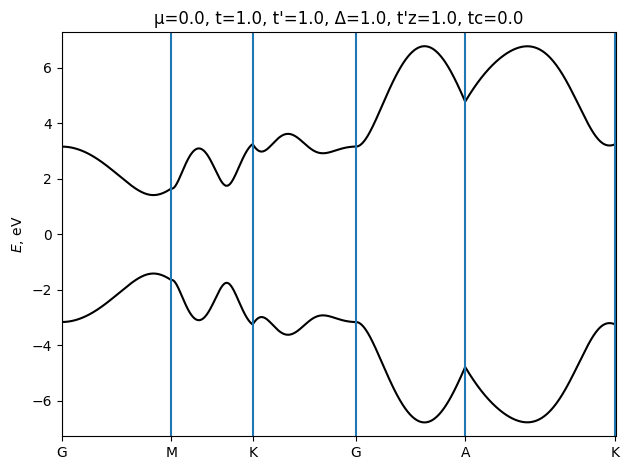

In [47]:
result.results['tabulate'].plot_path_fat(path,                                                                                           
                                         close_fig=False,
                                         show_fig=False,
                                         Eshift=0
                                         )
plt.title(f"μ={my_model.mu}, t={my_model.t}, t'={my_model.tp}, Δ={my_model.Delta}, t'z={my_model.tpz}, tc={my_model.tc}")
plt.tight_layout()
plt.savefig('par1.pdf')
plt.show()